In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
#df --> https://www.kaggle.com/datasets/lodetomasi1995/income-classification/data

In [3]:
df = pd.read_csv("income_evaluation.csv")

In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [8]:
df.columns = ["age","workclass","fnlwgt","education","education_num","marital_status","occupation","relationship","race","sex","capital_gain","capital_loss","hours_per_week","native_country","income"]

In [9]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [10]:
categorical = [col for col in df.columns if df[col].dtype=='O']
numerical = [col for col in df.columns if df[col].dtype!='O']

In [11]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [12]:
numerical

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

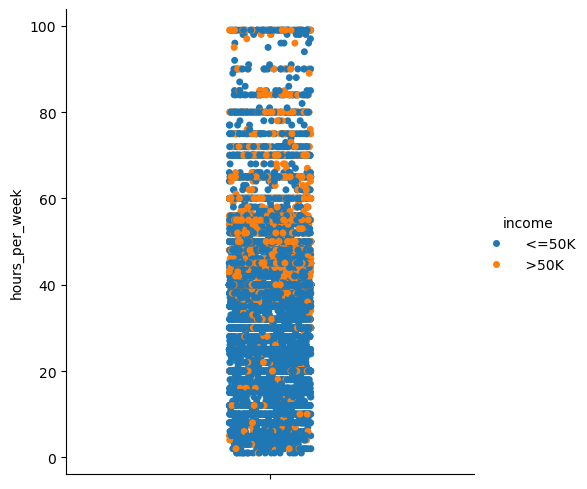

In [13]:
sns.catplot(y="hours_per_week", hue="income", data=df)
plt.show()

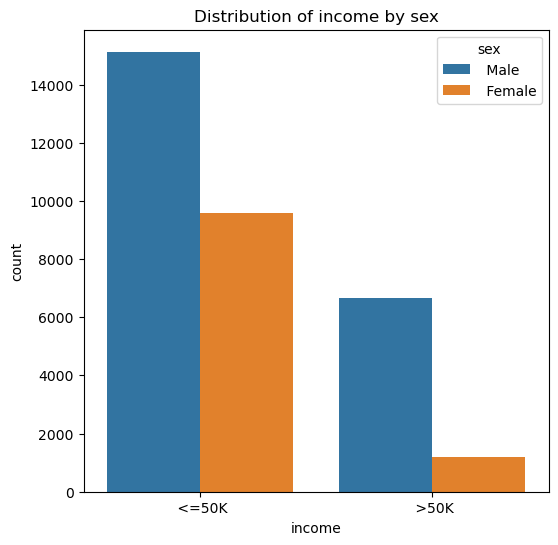

In [14]:
fig,ax = plt.subplots(figsize=(6,6))
ax = sns.countplot(x="income",hue="sex", data=df)
ax.set_title("Distribution of income by sex")
plt.show()

In [15]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [16]:
df["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [17]:
df["workclass"] = df["workclass"].replace(" ?",np.nan)

In [18]:
df["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', nan, ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [19]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [20]:
df["occupation"].unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [21]:
df["occupation"] = df["occupation"].replace(" ?",np.nan)

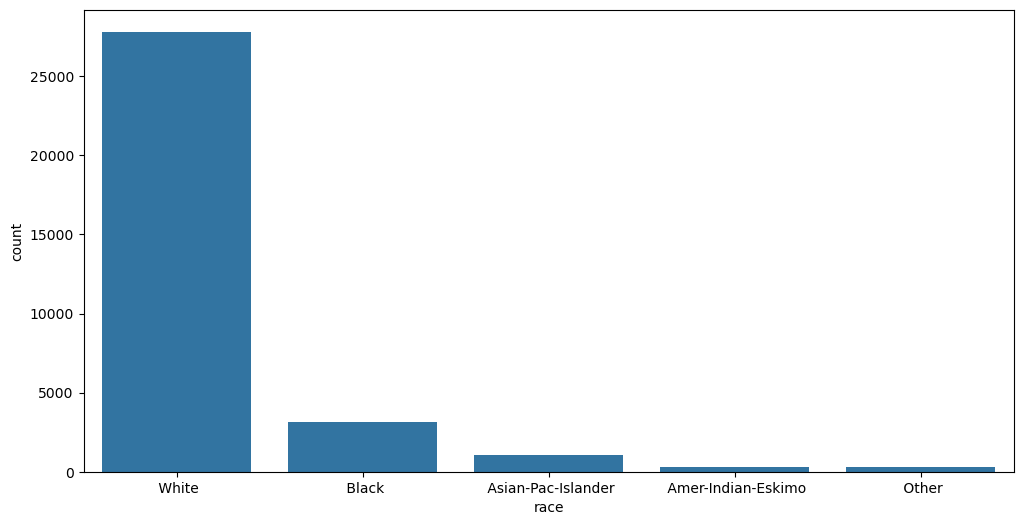

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(df["race"].value_counts())
plt.show()

In [23]:
df["native_country"].unique()

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [24]:
df["native_country"] = df["native_country"].replace(' ?',np.nan)

In [25]:
df["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [26]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [28]:
df[categorical].isnull().sum()

workclass         1836
education            0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
native_country     583
income               0
dtype: int64

In [29]:
df[numerical].isnull().sum()

age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64

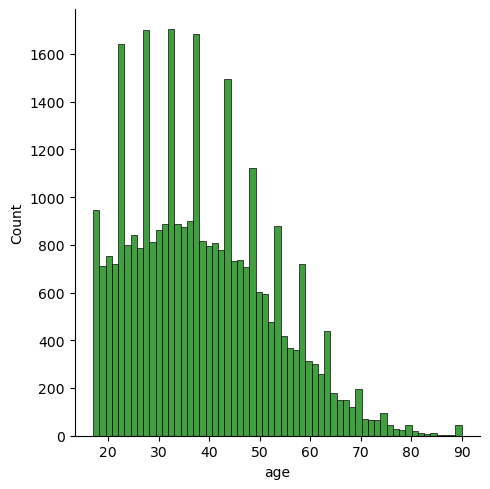

In [30]:
sns.displot(x="age", color = "green", data=df)
plt.show()

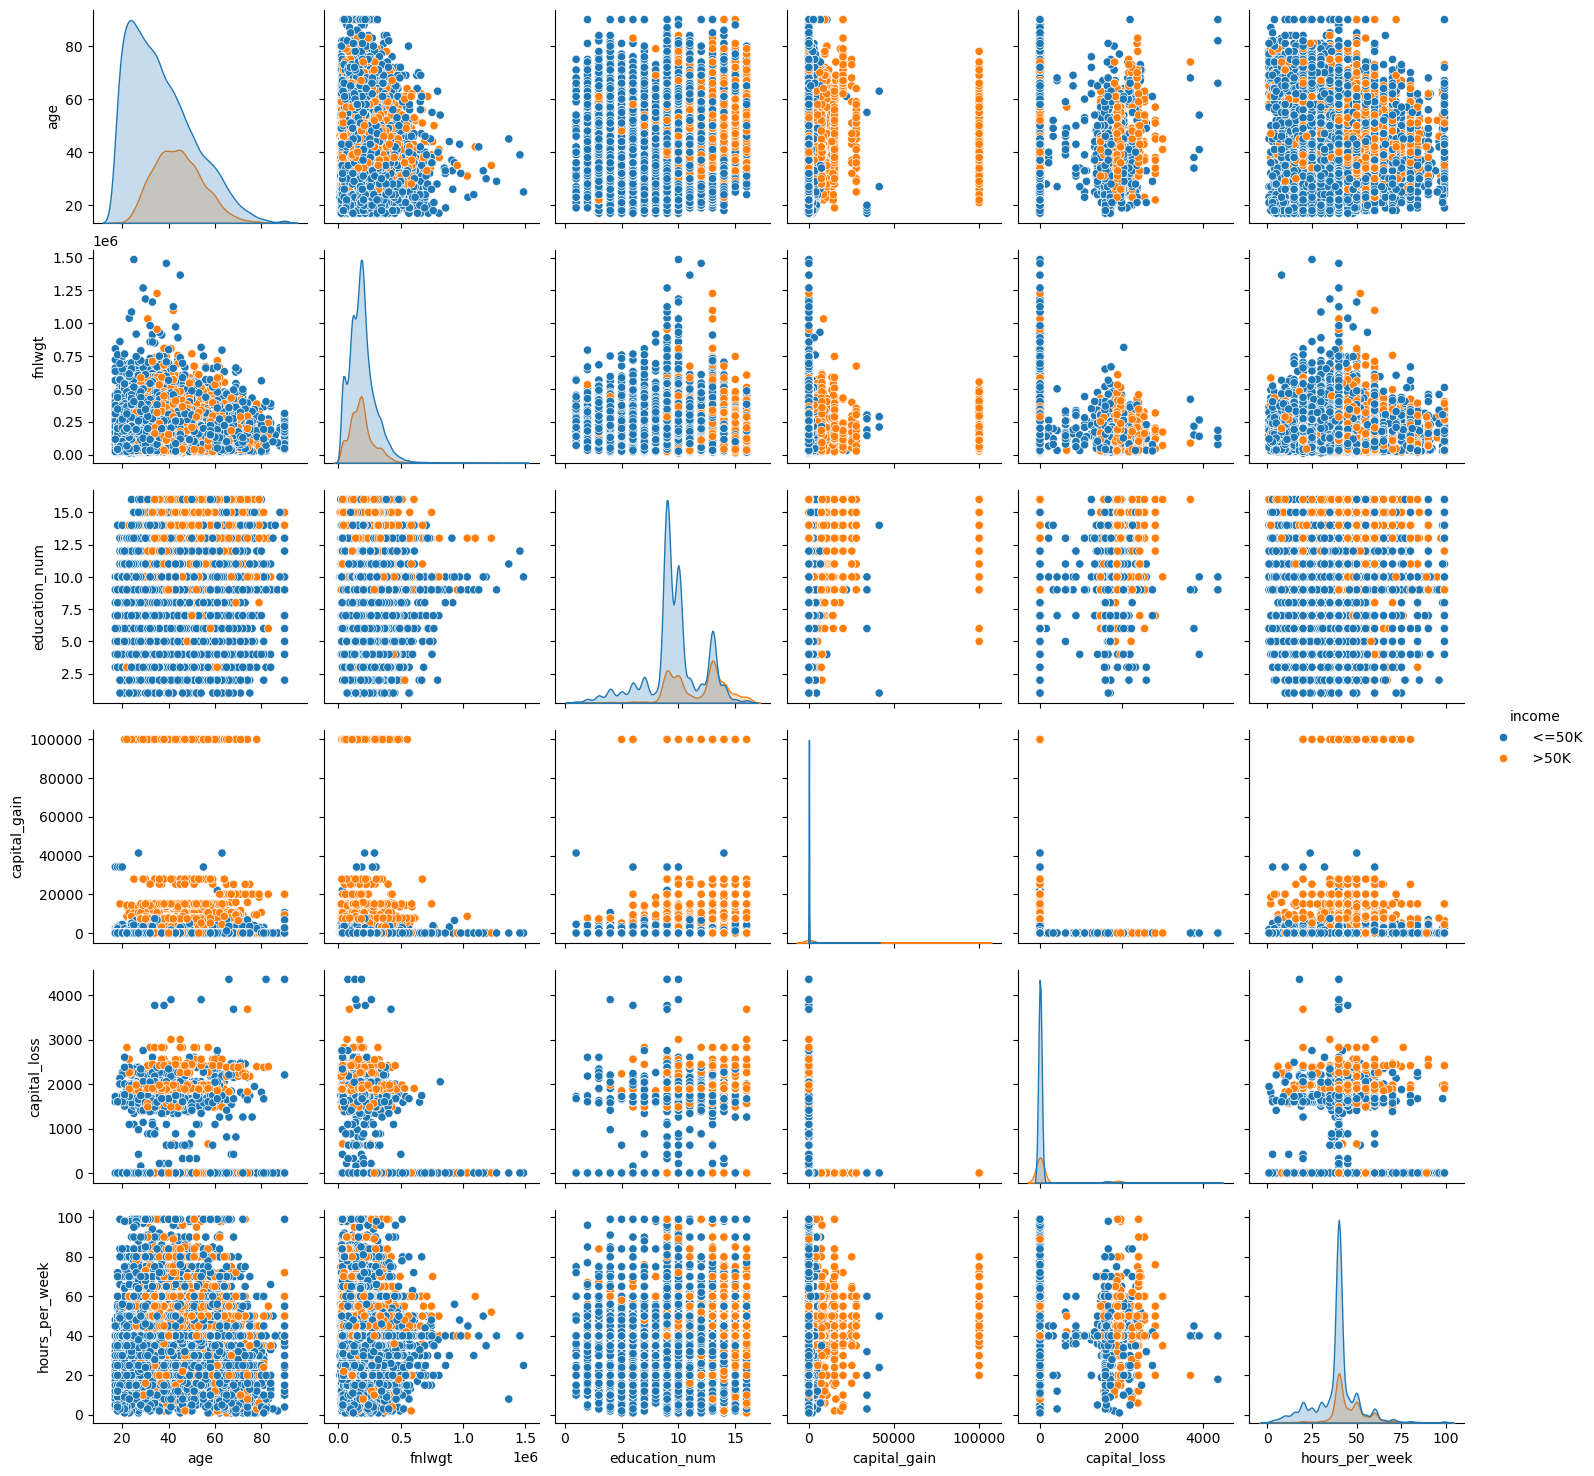

In [31]:
sns.pairplot(df, hue="income")
plt.show()

In [32]:
# features

In [33]:
X = df.drop(columns="income", axis=1)
y = df["income"]

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.3, random_state=42)

In [36]:
X_train.isnull().sum()

age                 0
workclass         546
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        549
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    188
dtype: int64

In [37]:
X_test.isnull().sum()

age                  0
workclass         1290
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1294
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     395
dtype: int64

In [38]:
X_train["workclass"].value_counts()

workclass
Private             6764
Self-emp-not-inc     805
Local-gov            628
State-gov            397
Self-emp-inc         331
Federal-gov          291
Without-pay            3
Never-worked           3
Name: count, dtype: int64

In [39]:
for i in [X_train,X_test]:
    i["workclass"] = i["workclass"].fillna(X_train["workclass"].mode()[0])
    i["occupation"] = i["occupation"].fillna(X_train["occupation"].mode()[0])
    i["native_country"] = i["native_country"].fillna(X_train["native_country"].mode()[0])

In [40]:
X_test.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [41]:
X_train.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [42]:
X_train.head(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
19838,24,Self-emp-not-inc,166036,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,United-States
3895,62,Private,182687,Some-college,10,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,45,United-States
31122,50,Private,28952,Some-college,10,Married-civ-spouse,Sales,Wife,White,Female,0,0,39,United-States
24934,18,Private,189487,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,35,United-States
31302,60,Private,85995,Masters,14,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male,0,0,50,South


In [43]:
categorical = [col for col in X_train.columns if X_train[col].dtype =='O']
numerical = [col for col in X_train.columns if X_train[col].dtype !='O']

In [44]:
X_train[categorical]

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
19838,Self-emp-not-inc,Some-college,Married-civ-spouse,Transport-moving,Husband,White,Male,United-States
3895,Private,Some-college,Married-civ-spouse,Exec-managerial,Wife,White,Female,United-States
31122,Private,Some-college,Married-civ-spouse,Sales,Wife,White,Female,United-States
24934,Private,Some-college,Never-married,Sales,Own-child,White,Female,United-States
31302,Private,Masters,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male,South
...,...,...,...,...,...,...,...,...
29802,Private,Bachelors,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
5390,Private,12th,Divorced,Other-service,Unmarried,White,Female,United-States
860,Private,11th,Never-married,Adm-clerical,Own-child,White,Female,United-States
15795,Self-emp-not-inc,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,United-States


In [45]:
X_train[categorical].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    40
dtype: int64

In [46]:
X_train["native_country"].unique()

array([' United-States', ' South', ' Mexico', ' England', ' Canada',
       ' Cambodia', ' Philippines', ' El-Salvador', ' Nicaragua', ' Iran',
       ' China', ' Japan', ' Germany', ' Cuba', ' Vietnam', ' Poland',
       ' Taiwan', ' Jamaica', ' Columbia', ' Dominican-Republic',
       ' Puerto-Rico', ' Yugoslavia', ' Outlying-US(Guam-USVI-etc)',
       ' Guatemala', ' Greece', ' Haiti', ' India', ' Italy', ' France',
       ' Ireland', ' Thailand', ' Hungary', ' Peru', ' Portugal',
       ' Trinadad&Tobago', ' Ecuador', ' Laos', ' Hong', ' Honduras',
       ' Scotland'], dtype=object)

In [47]:
y_train_binary = y_train.apply(lambda x:1 if x.strip() == '>50K' else 0)

In [48]:
y_train_binary

19838    0
3895     1
31122    0
24934    0
31302    1
        ..
29802    0
5390     0
860      0
15795    0
23654    0
Name: income, Length: 9768, dtype: int64

In [49]:
target_means = y_train_binary.groupby(X_train["native_country"]).mean()

In [50]:
target_means

native_country
Cambodia                      0.600000
Canada                        0.303030
China                         0.192308
Columbia                      0.000000
Cuba                          0.222222
Dominican-Republic            0.086957
Ecuador                       0.000000
El-Salvador                   0.093750
England                       0.343750
France                        0.666667
Germany                       0.295455
Greece                        0.333333
Guatemala                     0.090909
Haiti                         0.133333
Honduras                      0.000000
Hong                          0.400000
Hungary                       0.250000
India                         0.428571
Iran                          0.533333
Ireland                       0.250000
Italy                         0.380952
Jamaica                       0.130435
Japan                         0.400000
Laos                          0.142857
Mexico                        0.058824
Nicaragua 

In [51]:
y_train_binary.mean()

np.float64(0.24334561834561835)

In [52]:
X_train["native_country_encoded"] = X_train["native_country"].map(target_means)
X_train["native_country_encoded"] = X_train["native_country_encoded"].fillna(y_train_binary.mean())

X_test["native_country_encoded"] = X_test["native_country"].map(target_means)
X_test["native_country_encoded"] = X_test["native_country_encoded"].fillna(y_train_binary.mean())

In [53]:
X_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
19838,24,Self-emp-not-inc,166036,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,United-States,0.248205
3895,62,Private,182687,Some-college,10,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,45,United-States,0.248205
31122,50,Private,28952,Some-college,10,Married-civ-spouse,Sales,Wife,White,Female,0,0,39,United-States,0.248205
24934,18,Private,189487,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,35,United-States,0.248205
31302,60,Private,85995,Masters,14,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male,0,0,50,South,0.178571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0.248205
5390,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,0,21,United-States,0.248205
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,United-States,0.248205
15795,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,84,United-States,0.248205


In [54]:
X_train = X_train.drop("native_country", axis=1)
X_test = X_test.drop("native_country", axis=1)

In [55]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [56]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [57]:
X_train_encoded = pd.get_dummies(
    X_train, 
    columns=['workclass',
     'education',
     'marital_status',
     'occupation',
     'relationship',
     'race',
     'sex'],
    drop_first=True).astype(int)

In [58]:
X_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country_encoded
19838,24,Self-emp-not-inc,166036,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,0.248205
3895,62,Private,182687,Some-college,10,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,45,0.248205
31122,50,Private,28952,Some-college,10,Married-civ-spouse,Sales,Wife,White,Female,0,0,39,0.248205
24934,18,Private,189487,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,35,0.248205
31302,60,Private,85995,Masters,14,Married-civ-spouse,Adm-clerical,Husband,Asian-Pac-Islander,Male,0,0,50,0.178571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,0.248205
5390,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,0,21,0.248205
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,0.248205
15795,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,84,0.248205


In [59]:
X_train_encoded

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,native_country_encoded,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male
19838,24,166036,10,0,0,60,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3895,62,182687,10,0,0,45,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
31122,50,28952,10,0,0,39,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
24934,18,189487,10,0,0,35,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
31302,60,85995,14,0,0,50,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,359461,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
5390,31,147215,8,0,0,21,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
860,18,216284,7,0,0,20,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
15795,50,54261,9,0,0,84,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [60]:
X_test_encoded = pd.get_dummies(
    X_test, 
    columns=['workclass',
     'education',
     'marital_status',
     'occupation',
     'relationship',
     'race',
     'sex'],
    drop_first=True).astype(int)

In [61]:
X_test_encoded.shape

(22793, 58)

In [62]:
cols = X_train.columns

In [63]:
X_train_encoded

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,native_country_encoded,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male
19838,24,166036,10,0,0,60,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3895,62,182687,10,0,0,45,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
31122,50,28952,10,0,0,39,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
24934,18,189487,10,0,0,35,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
31302,60,85995,14,0,0,50,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,359461,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
5390,31,147215,8,0,0,21,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
860,18,216284,7,0,0,20,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
15795,50,54261,9,0,0,84,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [64]:
X_train_encoded.isnull().sum()

age                                      0
fnlwgt                                   0
education_num                            0
capital_gain                             0
capital_loss                             0
hours_per_week                           0
native_country_encoded                   0
workclass_ Local-gov                     0
workclass_ Never-worked                  0
workclass_ Private                       0
workclass_ Self-emp-inc                  0
workclass_ Self-emp-not-inc              0
workclass_ State-gov                     0
workclass_ Without-pay                   0
education_ 11th                          0
education_ 12th                          0
education_ 1st-4th                       0
education_ 5th-6th                       0
education_ 7th-8th                       0
education_ 9th                           0
education_ Assoc-acdm                    0
education_ Assoc-voc                     0
education_ Bachelors                     0
education_ 

In [65]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [67]:
rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,          
    min_samples_split=20, 
    min_samples_leaf=10,   
    max_features='sqrt',   
    random_state=42
)
rfc.fit(X_train_encoded,y_train)
train_acc = accuracy_score(y_train, rfc.predict(X_train_encoded))
test_acc = accuracy_score(y_test, rfc.predict(X_test_encoded))
print(f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
print(classification_report(y_test, rfc.predict(X_test_encoded)))

Train Acc: 0.864 | Test Acc: 0.854
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     17329
           1       0.78      0.54      0.64      5464

    accuracy                           0.85     22793
   macro avg       0.83      0.75      0.77     22793
weighted avg       0.85      0.85      0.84     22793



In [68]:
reg = LogisticRegression()
reg.fit(X_train_encoded,y_train)
train_acc = accuracy_score(y_train, reg.predict(X_train_encoded))
test_acc = accuracy_score(y_test, reg.predict(X_test_encoded))
print(f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
print(classification_report(y_test, reg.predict(X_test_encoded)))

Train Acc: 0.796 | Test Acc: 0.797
              precision    recall  f1-score   support

           0       0.81      0.97      0.88     17329
           1       0.71      0.26      0.38      5464

    accuracy                           0.80     22793
   macro avg       0.76      0.61      0.63     22793
weighted avg       0.78      0.80      0.76     22793



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
xgb = XGBClassifier()
xgb.fit(X_train_encoded,y_train)
train_acc = accuracy_score(y_train, xgb.predict(X_train_encoded))
test_acc = accuracy_score(y_test, xgb.predict(X_test_encoded))
print(f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
print(classification_report(y_test, xgb.predict(X_test_encoded)))

Train Acc: 0.936 | Test Acc: 0.862
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     17329
           1       0.74      0.66      0.70      5464

    accuracy                           0.86     22793
   macro avg       0.82      0.79      0.80     22793
weighted avg       0.86      0.86      0.86     22793



In [70]:
import sys
!{sys.executable} -m pip install shap

In [71]:
import shap

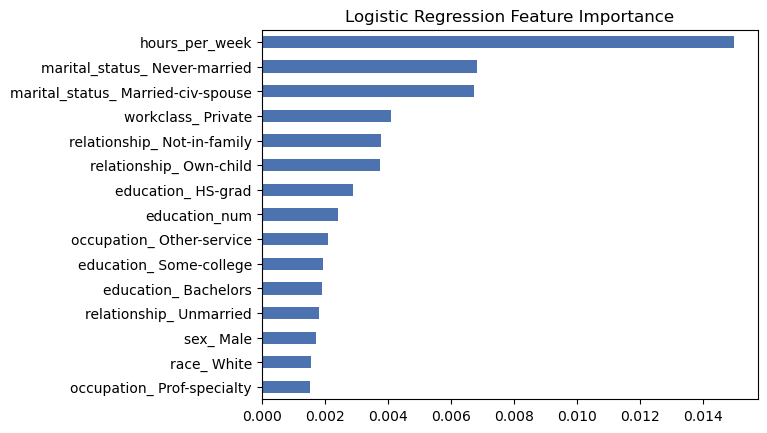

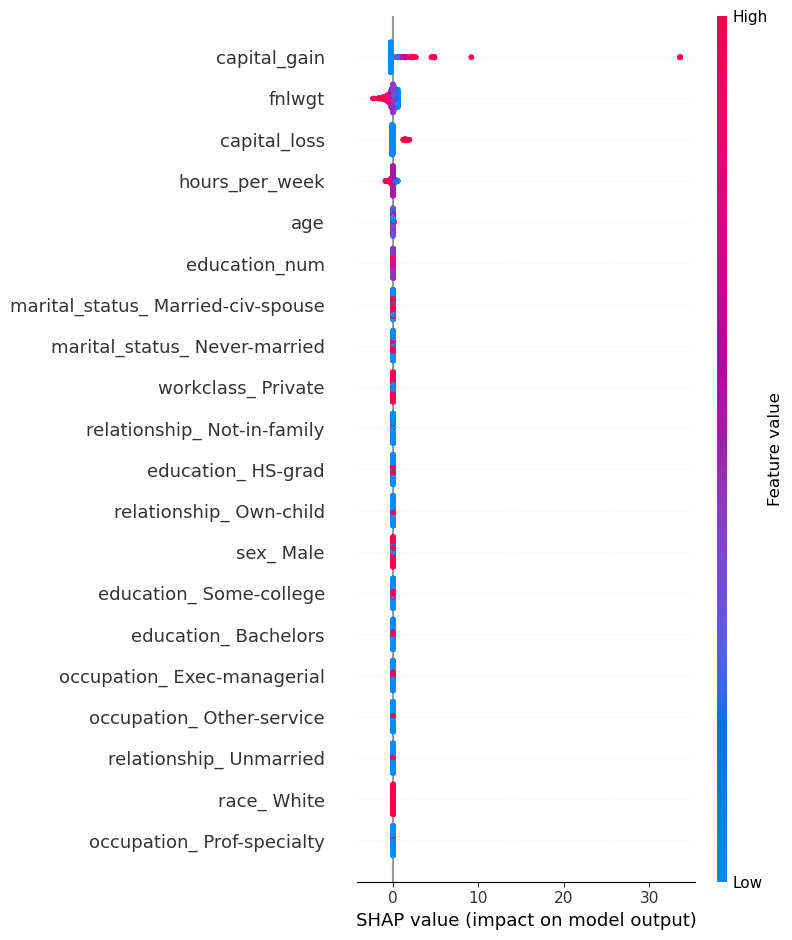

In [72]:
fi_lr = pd.Series(abs(reg.coef_[0]), index=X_train_encoded.columns).sort_values(ascending=False)
fi_lr.head(15).plot(kind="barh", color="#4C72B0", title="Logistic Regression Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# SHAP
explainer = shap.LinearExplainer(reg, X_train_encoded)
shap_values = explainer.shap_values(X_test_encoded[:1000])
shap.summary_plot(shap_values, X_test_encoded[:1000], feature_names=X_train_encoded.columns)

In [73]:
import sys
!{sys.executable} -m pip install lime

In [74]:
import lime

In [75]:
import warnings
warnings.filterwarnings("ignore")

In [76]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_encoded.values,           
    feature_names=X_train_encoded.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

lime_importances = np.zeros(X_train_encoded.shape[1])

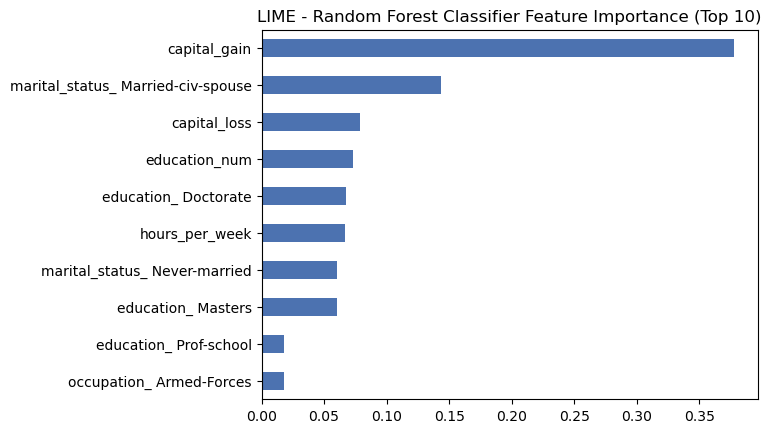

In [77]:
for i in range(50):
    exp = explainer_lime.explain_instance(
        X_test_encoded.values[i],            
        rfc.predict_proba, 
        num_features=10
    )
    for feat_idx, weight in exp.as_map()[1]:
        lime_importances[feat_idx] += abs(weight)

lime_importances /= 50
top_rf = pd.Series(
    lime_importances, 
    index=X_train_encoded.columns
).sort_values(ascending=False).head(10)

top_rf.plot(kind="barh", color="#4C72B0", title="LIME - Random Forest Classifier Feature Importance (Top 10)")
plt.gca().invert_yaxis()
plt.show()

top_rf_list = top_rf.index.tolist()

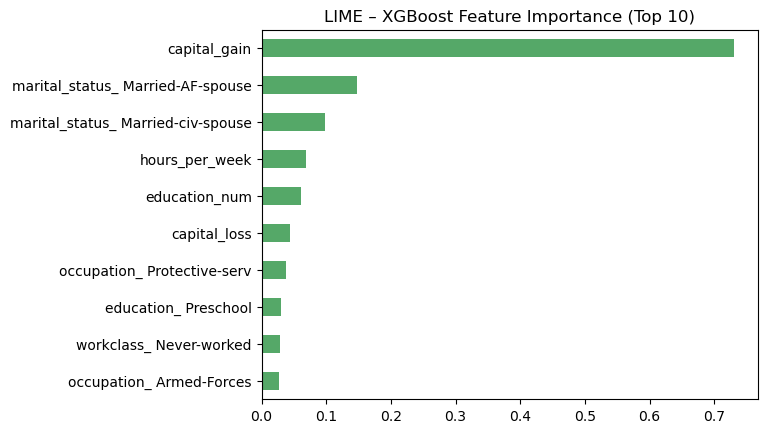

In [78]:
lime_importances_xgb = np.zeros(X_train_encoded.shape[1])

for i in range(50):
    exp = explainer_lime.explain_instance(
        X_test_encoded.values[i], 
        xgb.predict_proba,
        num_features=10
    )
    for feat_idx, weight in exp.as_map()[1]:
        lime_importances_xgb[feat_idx] += abs(weight)

lime_importances_xgb /= 50
top_xgb = pd.Series(
    lime_importances_xgb, 
    index=X_train_encoded.columns
).sort_values(ascending=False).head(10)

top_xgb.plot(kind="barh", color="#55A868", title="LIME – XGBoost Feature Importance (Top 10)")
plt.gca().invert_yaxis()
plt.show()

top_xgb_list = top_xgb.index.tolist()

In [79]:
import sys
!{sys.executable} -m pip install matplotlib_venn

In [80]:
lime_importances_lr = np.zeros(X_train_encoded.shape[1])

for i in range(50):
    exp = explainer_lime.explain_instance(
        X_test_encoded.values[i], 
        reg.predict_proba, 
        num_features=10
    )
    for feat_idx, weight in exp.as_map()[1]:
        lime_importances_lr[feat_idx] += abs(weight)

lime_importances_lr /= 50
top_lr = pd.Series(
    lime_importances_lr, 
    index=X_train_encoded.columns
).sort_values(ascending=False).head(10)

top_lr_list = top_lr.index.tolist()

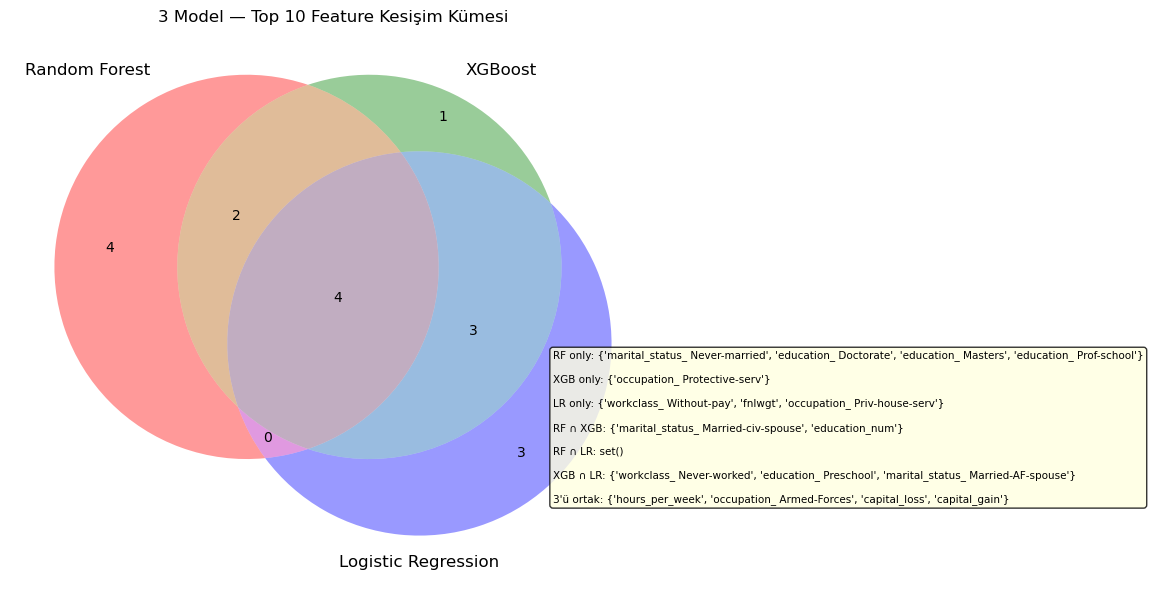

In [81]:
from matplotlib_venn import venn3

plt.figure(figsize=(10, 6))
v = venn3([set(top_rf_list), set(top_xgb_list), set(top_lr_list)],
          set_labels=("Random Forest", "XGBoost", "Logistic Regression"))
plt.title("3 Model — Top 10 Feature Kesişim Kümesi")

text = (
    f"RF only: {set(top_rf_list) - set(top_xgb_list) - set(top_lr_list)}\n\n"
    f"XGB only: {set(top_xgb_list) - set(top_rf_list) - set(top_lr_list)}\n\n"
    f"LR only: {set(top_lr_list) - set(top_rf_list) - set(top_xgb_list)}\n\n"
    f"RF ∩ XGB: {set(top_rf_list) & set(top_xgb_list) - set(top_lr_list)}\n\n"
    f"RF ∩ LR: {set(top_rf_list) & set(top_lr_list) - set(top_xgb_list)}\n\n"
    f"XGB ∩ LR: {set(top_xgb_list) & set(top_lr_list) - set(top_rf_list)}\n\n"
    f"3'ü ortak: {set(top_rf_list) & set(top_xgb_list) & set(top_lr_list)}"
)
plt.gcf().text(0.72, 0.15, text, fontsize=7.5, verticalalignment='bottom',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

rfc.fit(X_train_encoded, y_train)
xgb.fit(X_train_encoded, y_train)
reg.fit(X_train_encoded, y_train)

LogisticRegression()

In [83]:
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              precision_score, matthews_corrcoef, log_loss)
from sklearn.metrics import r2_score, mean_squared_error

def get_metrics(model, X, y, split_name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    acc       = accuracy_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    recall    = recall_score(y, y_pred)       
    precision = precision_score(y, y_pred)
    mse       = mean_squared_error(y, y_pred)
    r2        = r2_score(y, y_pred)
    entropy   = log_loss(y, y_proba)
    
    tn = ((y == 0) & (y_pred == 0)).sum()
    fp = ((y == 0) & (y_pred == 1)).sum()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_score = np.sqrt(recall * specificity)

    return {
        "Split":       split_name,
        "Accuracy":    round(acc, 4),
        "F1-Score":    round(f1, 4),
        "Sensitivity": round(recall, 4),
        "Recall":      round(recall, 4),
        "Precision":   round(precision, 4),
        "Specificity": round(specificity, 4),
        "G-Score":     round(g_score, 4),
        "R2":          round(r2, 4),
        "MSE":         round(mse, 4),
        "Entropy":     round(entropy, 4),
    }

model_dict = {
    "Random Forest":       rfc,
    "XGBoost":             xgb,
    "Logistic Regression": reg
}

rows = []
for name, model in model_dict.items():
    train_m = get_metrics(model, X_train_encoded, y_train, "Train")
    test_m  = get_metrics(model, X_test_encoded,  y_test,  "Test")
    train_m["Model"] = name
    test_m["Model"]  = name
    rows.extend([train_m, test_m])

results_df = pd.DataFrame(rows).set_index(["Model", "Split"])
results_df

Accuracy  F1-Score  Sensitivity  Recall  Precision  \
Model               Split                                                       
Random Forest       Train    0.8645    0.6718       0.5700  0.5700     0.8177   
                    Test     0.8539    0.6399       0.5414  0.5414     0.7823   
XGBoost             Train    0.9359    0.8618       0.8212  0.8212     0.9066   
                    Test     0.8623    0.6954       0.6556  0.6556     0.7404   
Logistic Regression Train    0.7965    0.3939       0.2718  0.2718     0.7154   
                    Test     0.7974    0.3807       0.2597  0.2597     0.7127   

                           Specificity  G-Score      R2     MSE  Entropy  
Model               Split                                                 
Random Forest       Train       0.9591   0.7394  0.2639  0.1355   0.2979  
                    Test        0.9525   0.7181  0.1986  0.1461   0.3201  
XGBoost             Train       0.9728   0.8938  0.6519  0.0641   0.1660  
                    Test        0.9275   0.7798  0.2446  0.1377   0.3007  
Logistic Regression Train       0.9652   0.5122 -0.1053  0.2035   0.5130  
                    Test        0.9670   0.5011 -0.1114  0.2026   0.5167